## Aula 03
- Embeddings
- Distância Euclidiana
- Distância de Cosseno

É Nescessario dar "Run" em cada bloco de código para que as funções fiquem disponiveis!

In [1]:
# Imports

from google.colab import userdata
import requests
import math

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd

import re
import spacy

## Criação da função get_embedings
- Checa se a chave OPENROUTER_API_KEY existe
- É preciso fazer a configuração da mesma no Colab

In [9]:
# Checa se tem a API KEY
openrouter_api_key = userdata.get('OPENROUTER_API_KEY')

# Se não solta um erro
if not openrouter_api_key:
  raise ValueError("OPENROUTER_API_KEY is not set in Colab secrets.")

def get_embeddings(text):
  response = requests.post(
      "https://openrouter.ai/api/v1/embeddings",
  headers={
    "Authorization": f"Bearer {openrouter_api_key}",
    "Content-Type": "application/json",
  },
  json={
    "model": "openai/text-embedding-3-small",
    "input": f"{text}"
  }
  )

  data = response.json()
  embedding = data["data"][0]["embedding"]

  print(f"Embedding dimension: {len(embedding)}")
  print(embedding)
  return embedding, data

# Testando se está funcionando
#get_embeddings("The quick brown fox jumps over the lazy dog")

## Criação da função distancia_euclidiana, sem utilizar bibliotecas externas, para explicar oque está sendo feito.

In [10]:
def distancia_euclidiana(vetor1, vetor2):
    soma_quadrados = sum((a - b) ** 2 for a, b in zip(vetor1, vetor2))
    return math.sqrt(soma_quadrados)

## Criação da função distancia_cosseno, sem utilizar bibliotecas externas, para explicar oque está sendo feito.

In [11]:
def distancia_cosseno(vetor1, vetor2):
    produto_escalar = sum(a * b for a, b in zip(vetor1, vetor2))

    magnitude1 = math.sqrt(sum(a ** 2 for a in vetor1))
    magnitude2 = math.sqrt(sum(b ** 2 for b in vetor2))

    if magnitude1 == 0 or magnitude2 == 0:
        return 1.0

    similaridade = produto_escalar / (magnitude1 * magnitude2)
    return 1.0 - similaridade

Similaridade de Cosseno

In [12]:

def similaridade_cosseno(vec1: np.ndarray, vec2: np.ndarray) -> float:
    norm_v1 = np.linalg.norm(vec1)
    norm_v2 = np.linalg.norm(vec2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm_v1 * norm_v2))

## Testando com os dados fornecidos

In [ ]:
dados_categorias = {
    "animal": ["gato", "felino", "cachorro"],
    "veiculo": ["carro", "caminhão", "moto"],
    "fruta": ["banana", "maçã", "goiaba"]
}

# 1. Obter primeiro os embeddings dos temas/âncoras
banco_temas = {}
for tema in dados_categorias.keys():
    print(f"Buscando embedding do tema: {tema}...")
    embedding_tema, _ = get_embeddings(tema)
    banco_temas[tema] = embedding_tema

# 2. Processar cada palavra e calcular as métricas
lista_resultados = []

for tema, palavras in dados_categorias.items():
    vetor_tema = banco_temas[tema]

    for palavra in palavras:
        print(f"Processando palavra: {palavra}...")
        vetor_palavra, _ = get_embeddings(palavra)

        # Cálculos de distância da palavra contra o seu tema
        dist_euclidiana = distancia_euclidiana(vetor_palavra, vetor_tema)
        dist_cosseno = distancia_cosseno(vetor_palavra, vetor_tema)

        # Salva os dados estruturados (guardamos apenas o tamanho do embedding para visualização na tabela)
        lista_resultados.append({
            "Tema": tema,
            "Palavra": palavra,
            "Dimensão Embedding": len(vetor_palavra),
            "Distância Euclidiana": round(dist_euclidiana, 4),
            "Distância de Cosseno": round(dist_cosseno, 4)
        })

# --- Geração da Tabela ---
df = pd.DataFrame(lista_resultados)

# Exibe a tabela formatada no ambiente do Colab
print("\n--- TABELA DE DISTÂNCIAS POR TEMA ---")
display(df)

Buscando embedding do tema: animal...
Embedding dimension: 1536
[0.03936767578125, 0.0206451416015625, -0.0235748291015625, 0.09698486328125, -0.0258026123046875, -0.004974365234375, -0.0039520263671875, 0.0207977294921875, 0.00667572021484375, 0.019256591796875, 0.006153106689453125, -0.0182952880859375, 0.01032257080078125, -0.02874755859375, 0.00955963134765625, 0.0265655517578125, 0.005340576171875, -0.004817962646484375, 0.0174713134765625, 0.0013132095336914062, 0.077880859375, 0.005443572998046875, -0.0439453125, -0.034393310546875, -0.006549835205078125, -0.003978729248046875, 0.0010309219360351562, 0.0300750732421875, 0.036376953125, -0.01412200927734375, 0.033416748046875, -0.038848876953125, 0.044525146484375, -0.022979736328125, -0.007556915283203125, 0.0128326416015625, 0.0006284713745117188, -0.056793212890625, -0.03167724609375, -0.021697998046875, -0.01250457763671875, -0.052093505859375, 0.03704833984375, 0.045623779296875, 0.0104217529296875, 0.036865234375, -0.052551

,Tema,Palavra,Dimensão Embedding,Distância Euclidiana,Distância de Cosseno
0,animal,gato,1536,1.0467,0.5476
1,animal,felino,1536,1.0056,0.5054
2,animal,cachorro,1536,1.0932,0.5976
3,veiculo,carro,1536,0.8512,0.3622
4,veiculo,caminhão,1536,0.9081,0.4123
5,veiculo,moto,1536,1.0440,0.5450
6,fruta,banana,1536,1.0790,0.5824
7,fruta,maçã,1536,0.9676,0.4682
8,fruta,goiaba,1536,1.0508,0.5521


## Geração de Grafico dos embeddings

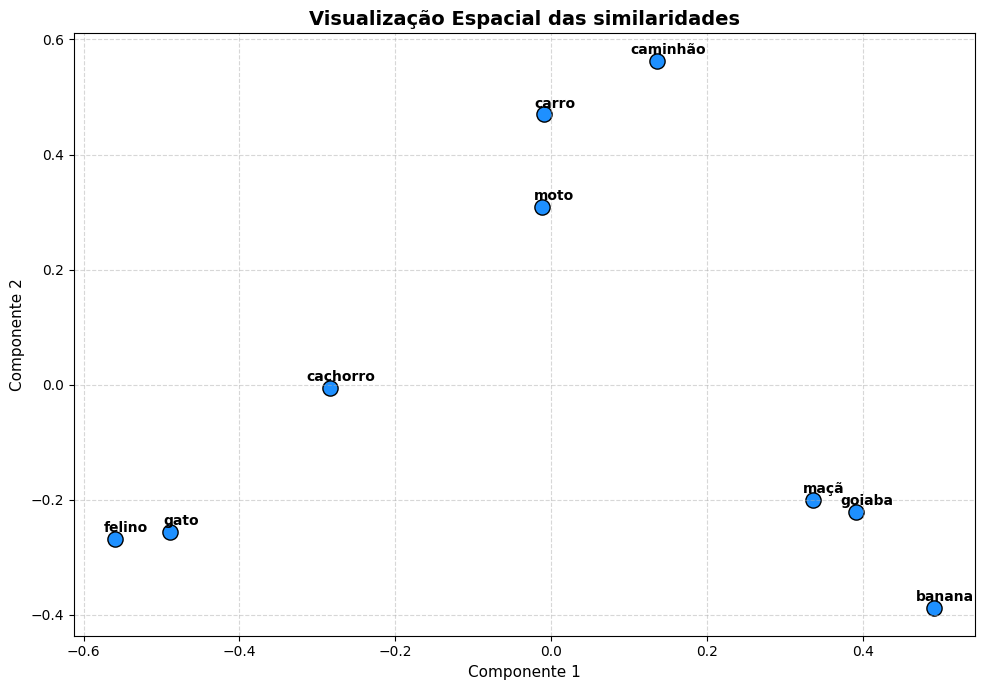

In [ ]:

# Extrair as palavras e os vetores na mesma ordem
labels = list(banco_embeddings.keys())
vetores = list(banco_embeddings.values())

# Reduz a dimensão dos embeddings usando PCA
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)

plt.figure(figsize=(10, 7))

# Plota os pontos
plt.scatter(vetores_2d[:, 0], vetores_2d[:, 1], color='dodgerblue', edgecolors='k', s=120)

# Adiciona o texto de cada palavra ao lado do seu ponto
for i, palavra in enumerate(labels):
    plt.annotate(
        palavra,
        (vetores_2d[i, 0], vetores_2d[i, 1]),
        textcoords="offset points",
        xytext=(8, 5),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Estilização do gráfico
plt.title("Visualização Espacial das similaridades", fontsize=14, fontweight='bold')
plt.xlabel("Componente 1", fontsize=11)
plt.ylabel("Componente 2", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Agora testando a comparação com frases

In [ ]:
# Pode realizar mais testes mudando a frase ancora para uma negação, ou as frases de comparação

frase_ancora = "O cachorro correu no parque e brincou com a bola."

frases_comparacao = [
    ("Similar (mesmo sentido, palavras diferentes)", "Um cão estava correndo no jardim e brincando com seu brinquedo."),
    ("Relacionado (mesmo contexto de animais)", "O gato dormiu na almofada da sala durante toda a tarde."),
    ("Diferente (outro domínio - economia)", "A taxa de juros do banco central subiu dois pontos percentuais."),
    ("Oposto/Negação", "Nenhum animal esteve no parque e o cão permaneceu preso em casa.")
]

embedding_ancora, _ = get_embeddings(frase_ancora)
vec_ancora = np.array(embedding_ancora, dtype=np.float32)

vecs_comp = []
for _, frase_texto in frases_comparacao:
    embedding_result, _ = get_embeddings(frase_texto)
    vecs_comp.append(np.array(embedding_result, dtype=np.float32))

resultados = []
for i, (tipo_frase, texto_frase) in enumerate(frases_comparacao):
    vec = vecs_comp[i]
    resultados.append({
        "Texto": tipo_frase,
        "Frase Original": texto_frase,
        "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
        "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
        "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

Embedding dimension: 1536
[0.0153656005859375, 0.041229248046875, -0.007350921630859375, 0.01381683349609375, 0.01090240478515625, 0.01055908203125, 0.024688720703125, 0.038116455078125, -0.015533447265625, -0.006061553955078125, 0.018798828125, 0.0074310302734375, -0.005947113037109375, -0.0012664794921875, 0.0237579345703125, -0.0247802734375, -0.004283905029296875, -0.0015935897827148438, 0.019195556640625, 0.0286712646484375, -0.0265045166015625, 0.03826904296875, -0.040435791015625, -0.0244598388671875, 0.0096282958984375, -0.0153045654296875, -0.0176239013671875, -0.0104217529296875, -0.0012006759643554688, 0.032470703125, -0.01519012451171875, -0.004329681396484375, -0.033935546875, -0.0517578125, 0.00154876708984375, 0.0242462158203125, -0.02008056640625, -0.061920166015625, 0.034759521484375, 0.0139312744140625, -0.006526947021484375, -0.0276031494140625, 0.0142059326171875, -0.0021991729736328125, 0.057464599609375, -0.00482940673828125, 0.01529693603515625, -0.03182983398437

,Texto,Frase Original,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Similar (mesmo sentido, palavras diferentes)",Um cão estava correndo no jardim e brincando c...,0.6839,0.7661,0.2339
1,Relacionado (mesmo contexto de animais),O gato dormiu na almofada da sala durante toda...,1.1139,0.3796,0.6204
2,Diferente (outro domínio - economia),A taxa de juros do banco central subiu dois po...,1.2395,0.2317,0.7683
3,Oposto/Negação,Nenhum animal esteve no parque e o cão permane...,0.9266,0.5707,0.4293


## Busca Semântica Simples Manual (Embedding por Embedding)

A Busca Semântica substitui a busca simples por palavra-chave .

Nesta etapa:

1. Lemos os arquivos de markdown gerados na aula 2.
2. Separamos o texto linha por linha.
3. Geramos o embedding para cada linha.
4. Definimos uma pergunta (*query*) de busca. (O que é “**Autonomia e opacidade algorítmica**”?, O que é o diário de bordo da IA? e etc)
5. Geramos o embedding da query e calculamos a Similaridade de Cosseno contra cada trecho.
6. Retornamos o TOP 3 com maior score!
7. Dividir os documentos agora por trechos maiores (parágrafo) e repetir a etapa anterior.
8. Dividir os documentos agora por trechos maiores (capitulos) e repetir a etapa anterior.

In [ ]:
nlp = spacy.load("en_core_web_sm")

with open("/content/sample_data/bioetica_e_ia.md","r",encoding="utf-8") as file:
    text = file.read()

# Remove HTML comments
text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
# Remove Markdown headings:
text = re.sub(r'^#+.*$', '', text, flags=re.MULTILINE)
# Remove lines containing only numbers:
text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)
# Fix words broken by PDF extraction:
text = re.sub(r'(\w+)\s+-\s+(\w+)', r'\1\2', text)
text = re.sub(r'\n+', '\n', text)
text = text.strip()

doc = nlp(text)

sentences = [
    sent.text.strip()
    for sent in doc.sents
    if sent.text.strip()
]

first_5_sentences = sentences[:5]
print(first_5_sentences)

for sentence in sentences[:5]:
    print(sentence)

#print(f"Found {len(sentences)} sentences.\n")

#for i, sentence in enumerate(sentences, start=1):
#    print(f"{i}: {sentence}")

['Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1\n1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.', 'O avanço da inteligência artificial tem transformado profundamente a prática médica.', 'De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados.', 'Contudo, essa revolução tecnológica impõe desafios éticos significativos aos princípios clássicos da bioética, como beneficência, não maleficência, confidencialidade e respeito à autonomia do doente, consagrados desde o Juramento de Hipócrates.', 'A incorporação da inteligência artificial na medicina suscita tensões entre eficiência automatizada e valores humanos.']
Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1
1. Faculdade de Medicina da Universidade do Porto, Porto, Portuga

In [ ]:
# Reptindo código anterio para caso queira testar separadamente
# mantendo o teste com apenas 3 sentenças

frase_ancora = "Medicina no ambito moderno"

frases_comparacao = sentences[:3]

for frase in frases_comparacao:
    print(frase)

embedding_ancora, _ = get_embeddings(frase_ancora)
vec_ancora = np.array(embedding_ancora, dtype=np.float32)

vecs_comp = []
for frase_texto in frases_comparacao:
    embedding_result, _ = get_embeddings(frase_texto)
    vecs_comp.append(np.array(embedding_result, dtype=np.float32))

resultados = []
for i, texto_frase in enumerate(frases_comparacao):
    vec = vecs_comp[i]
    resultados.append({
        "Texto": texto_frase,
        "Frase Original": texto_frase,
        "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
        "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
        "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1
1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.
O avanço da inteligência artificial tem transformado profundamente a prática médica.
De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados.
Embedding dimension: 1536
[-0.00899505615234375, -0.01215362548828125, 0.03887939453125, 0.06585693359375, -0.0289154052734375, 0.01274871826171875, 0.0014162063598632812, 0.043212890625, -0.0374755859375, -0.009765625, -0.01256561279296875, -0.02935791015625, 0.0200653076171875, 0.00571441650390625, 0.0253448486328125, -0.01172637939453125, -0.0032253265380859375, -0.0419921875, 0.0787353515625, 0.04302978515625, -0.005458831787109375, -0.0051727294921875, 0.0167236328125, -0.036865234375, 0.01448059082

,Texto,Frase Original,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Juracy Barbosa dos Santos 1 , Guilhermina Rego...","Juracy Barbosa dos Santos 1 , Guilhermina Rego...",1.1112,0.3826,0.6174
1,O avanço da inteligência artificial tem transf...,O avanço da inteligência artificial tem transf...,1.0298,0.4698,0.5302
2,De sistemas de apoio à decisão clínica a algor...,De sistemas de apoio à decisão clínica a algor...,1.1165,0.3765,0.6235


### Por paragrafos

In [13]:
nlp = spacy.load("en_core_web_sm")


# Read Markdown file
with open(
    "/content/sample_data/bioetica_e_ia.md",
    "r",
    encoding="utf-8"
) as file:
    text = file.read()


# Remove HTML comments such as <!-- image -->
text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)

# Remove Markdown headings
text = re.sub(r'^#+.*$', '', text, flags=re.MULTILINE)

# Remove lines containing only numbers
text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)

# Fix words broken by PDF extraction
text = re.sub(r'(\w+)\s+-\s+(\w+)', r'\1\2', text)


paragraphs = [
    paragraph.strip()
    for paragraph in text.split("\n\n")
    if paragraph.strip()
]


frases_comparacao = paragraphs[:5]

for i, paragraph in enumerate(frases_comparacao, start=1):
    print(f"\n--- Paragraph {i} ---")
    print(paragraph)

# -----------

frase_ancora = "Medicina no ambito moderno"

frases_comparacao = paragraphs[:3]

for frase in frases_comparacao:
    print(frase)

embedding_ancora, _ = get_embeddings(frase_ancora)
vec_ancora = np.array(embedding_ancora, dtype=np.float32)

vecs_comp = []
for frase_texto in frases_comparacao:
    embedding_result, _ = get_embeddings(frase_texto)
    vecs_comp.append(np.array(embedding_result, dtype=np.float32))

resultados = []
for i, texto_frase in enumerate(frases_comparacao):
    vec = vecs_comp[i]
    resultados.append({
        "Texto": texto_frase,
        "Frase Original": texto_frase,
        "Dist. Euclidiana": round(distancia_euclidiana(vec_ancora, vec), 4),
        "Similaridade Cosseno": round(similaridade_cosseno(vec_ancora, vec), 4),
        "Distância Cosseno": round(distancia_cosseno(vec_ancora, vec), 4)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados


--- Paragraph 1 ---
Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1

--- Paragraph 2 ---
1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal.

--- Paragraph 3 ---
O avanço da inteligência artificial tem transformado profundamente a prática médica. De sistemas de apoio à decisão clínica a algoritmos de triagem e diagnóstico, a inteligência artificial tem demons -trado potencial para diagnósticos precoces, terapias personalizadas, otimização de recursos, redução de erros e ampliação do acesso a cuidados especializados. Contudo, essa revolução tecnológica impõe desafios éticos significativos aos princípios clássicos da bioética, como beneficência, não maleficência, confidencialidade e respeito à autonomia do doente, consagrados desde o Juramento de Hipócrates. A incorporação da inteligência artificial na medicina suscita tensões entre eficiência automatizada e valores humanos. Este artigo revisa a literatura sobre os principais dilemas éticos da aplicação da

,Texto,Frase Original,Dist. Euclidiana,Similaridade Cosseno,Distância Cosseno
0,"Juracy Barbosa dos Santos 1 , Guilhermina Rego...","Juracy Barbosa dos Santos 1 , Guilhermina Rego...",1.2144,0.2628,0.7372
1,1. Faculdade de Medicina da Universidade do Po...,1. Faculdade de Medicina da Universidade do Po...,1.1042,0.3902,0.6098
2,O avanço da inteligência artificial tem transf...,O avanço da inteligência artificial tem transf...,1.0778,0.4191,0.5809
